Zadanie 9

Stwórz kompletny dashboard EDA dla datasetu Penguins z 4 wykresami:
- Rozkład masy ciała (histogram z KDE)
- Scatter: bill_length vs bill_depth z kolorowaniem według gatunku
- Box plot: flipper_length według gatunku
- Bar plot: liczebność według gatunku i płci

Dataset: penguins = sns.load_dataset('penguins')

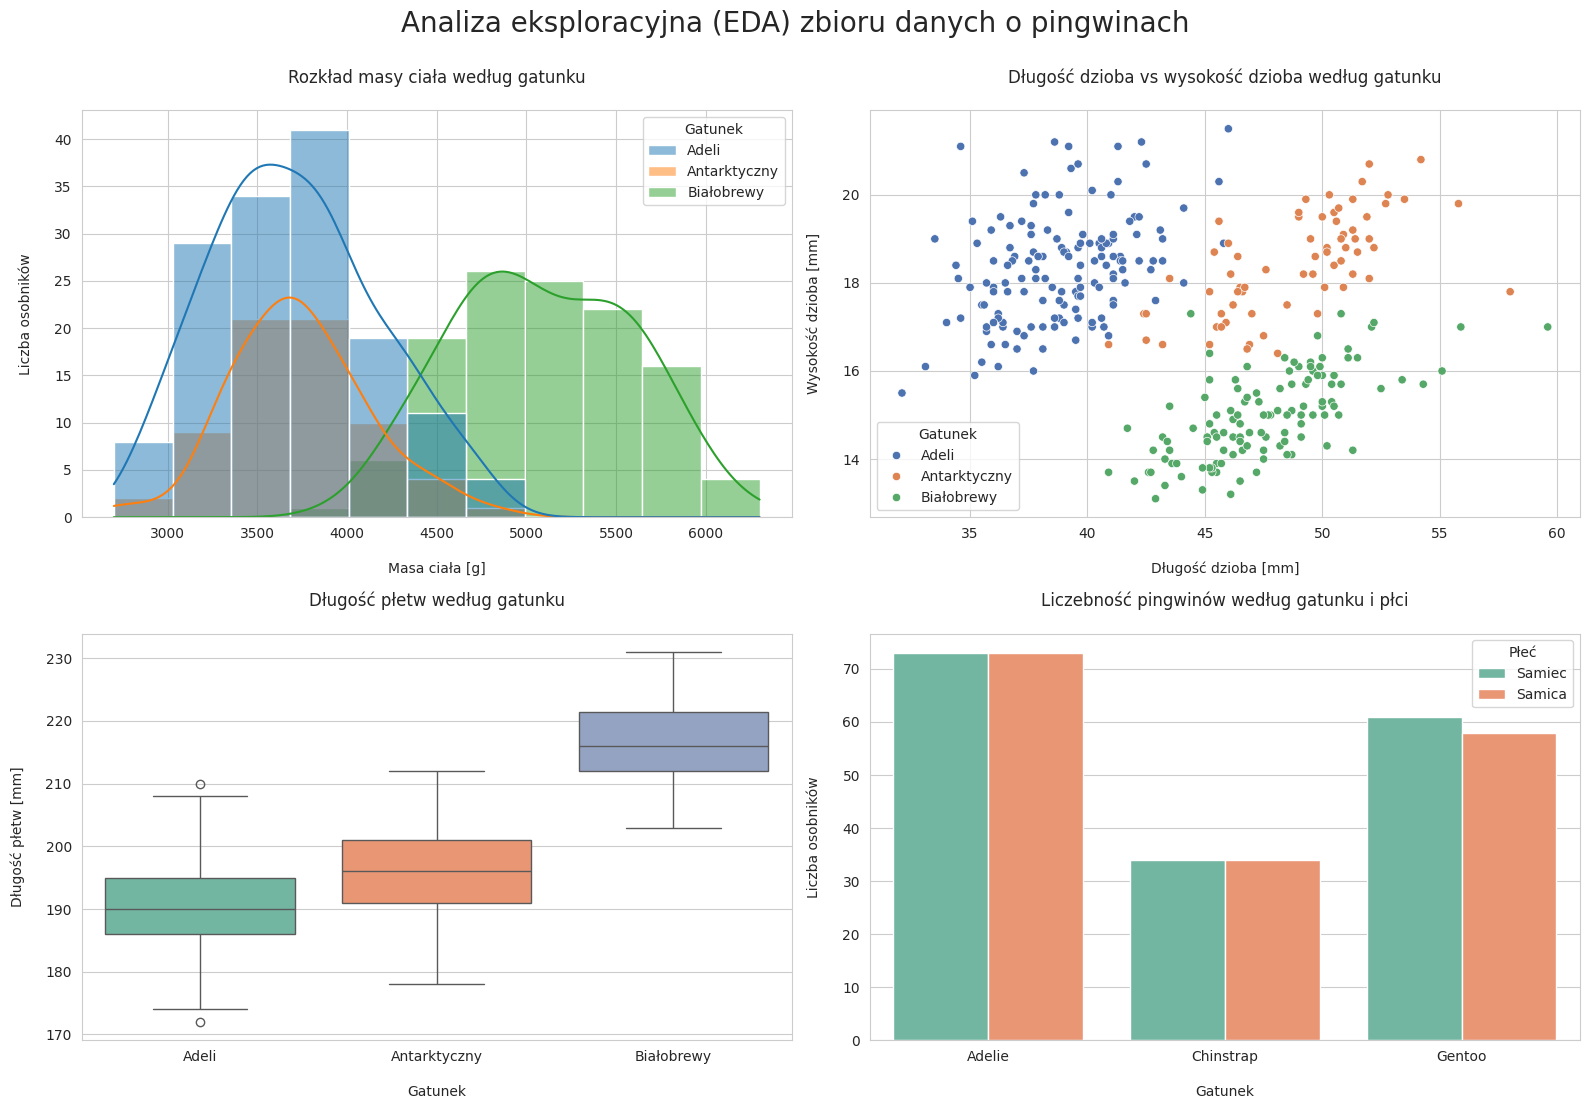

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Przygotowanie danych
penguins = sns.load_dataset('penguins').dropna(subset=['sex'])

sns.set_style("whitegrid")  # Dodaje siatkę, która ułatwia odczytywanie wartości

# Dashboard
# Utworzenie siatki dashboardu (2 wiersze, 2 kolumny)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analiza eksploracyjna (EDA) zbioru danych o pingwinach', fontsize=20, y=0.95)

# Wykres 1: Rozkład masy ciała (histogram z KDE)
sns.histplot(data=penguins, x='body_mass_g', kde=True, hue='species', ax=axes[0, 0])
axes[0, 0].set_title('Rozkład masy ciała według gatunku', pad=20)
axes[0, 0].set_xlabel('Masa ciała [g]', labelpad=15)
axes[0, 0].set_ylabel('Liczba osobników', labelpad=15)

legend1 = axes[0,0].get_legend()
legend1.set_title('Gatunek')
for t, n in zip(legend1.texts, ['Adeli', 'Antarktyczny', 'Białobrewy']):
    t.set_text(n)

# Wykres 2: Scatter: bill_length vs bill_depth z kolorowaniem według gatunku
sns.scatterplot(data=penguins, x='bill_length_mm', y= 'bill_depth_mm', hue='species', ax=axes[0, 1], palette='deep')
axes[0, 1].set_title("Długość dzioba vs wysokość dzioba według gatunku", pad=20)
axes[0, 1].set_xlabel("Długość dzioba [mm]", labelpad=15)
axes[0, 1].set_ylabel("Wysokość dzioba [mm]", labelpad=15)

legend2 = axes[0, 1].get_legend()
legend2.set_title('Gatunek')
for t, n in zip(legend2.texts, ['Adeli', 'Antarktyczny', 'Białobrewy']):
    t.set_text(n)

# Wykres 3: Box plot: flipper_length według gatunku
sns.boxplot(data=penguins, x='species', y='flipper_length_mm', hue='species', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Długość płetw według gatunku', pad=20)
axes[1, 0].set_xlabel('Gatunek', labelpad=15)
axes[1, 0].set_ylabel('Długość płetw [mm]', labelpad=15)
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_xticklabels(['Adeli', 'Antarktyczny', 'Białobrewy'])

# Wykres 4: Bar plot: liczebność według gatunku i płci
sns.barplot(data=penguins, x='species', y='body_mass_g',
            hue='sex', estimator=len, ax=axes[1, 1], palette='Set2' )

axes[1, 1].set_title("Liczebność pingwinów według gatunku i płci", pad=20)
axes[1, 1].set_xlabel("Gatunek", labelpad=15)
axes[1, 1].set_ylabel("Liczba osobników", labelpad=15)

legend4 = axes[1, 1].get_legend()
legend4.set_title('Płeć')
for t, n in zip(legend4.texts, ['Samiec', 'Samica']):
    t.set_text(n)

# Optymalizacja odstępów
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
